# Active Learning for Guest Satisfaction Review Classification

This notebook explores a hotel review dataset and builds toward an active learning pipeline for guest satisfaction classification. The project uses review text and ratings to create satisfaction labels, train baseline text classification models, and compare active learning strategies.

Cell 1: Adding imports for dataset loading and review

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast # Needed for converting string representations of lists to actual lists with numeric values
from pathlib import Path

# Check current directory

Path.cwd()

WindowsPath('c:/Users/mitch/Desktop/CS Project/DataScienceProjects/HotelReviews/notebooks')

Cell 2: Load the dataset

In [13]:
# Define path to the raw dataset
dataset_path = Path("../data/raw/trip_advisor_hotel_reviews.csv")
# Load the dataset
reviews_df = pd.read_csv(dataset_path)
# Display the first few rows of the dataset
reviews_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\raw\\trip_advisor_hotel_reviews.csv'

Cell 3: Check shape

In [6]:
# Check the shape of the dataset
reviews_df.shape

(878561, 10)

Cell 4: Columns

In [7]:
# Display name of columns
reviews_df.columns

Index(['ratings', 'title', 'text', 'author', 'date_stayed', 'offering_id',
       'num_helpful_votes', 'date', 'id', 'via_mobile'],
      dtype='str')

Cell 5: Info

In [8]:
# Display data types of each column & non-null counts
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 878561 entries, 0 to 878560
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ratings            878561 non-null  str  
 1   title              878561 non-null  str  
 2   text               878561 non-null  str  
 3   author             878561 non-null  str  
 4   date_stayed        810967 non-null  str  
 5   offering_id        878561 non-null  int64
 6   num_helpful_votes  878561 non-null  int64
 7   date               878561 non-null  str  
 8   id                 878561 non-null  int64
 9   via_mobile         878561 non-null  bool 
dtypes: bool(1), int64(3), str(6)
memory usage: 61.2 MB


Cell 6: Missing values

In [9]:
# Check for missing values
reviews_df.isnull().sum()

ratings                  0
title                    0
text                     0
author                   0
date_stayed          67594
offering_id              0
num_helpful_votes        0
date                     0
id                       0
via_mobile               0
dtype: int64

Cell 7: Summarize

In [15]:
# Summary statistics
reviews_df.describe()

,offering_id,num_helpful_votes,id
count,8.785610e+05,878561.000000,8.785610e+05
mean,3.058972e+05,1.153104,8.633481e+07
std,4.388314e+05,2.898120,4.999254e+07
min,7.257200e+04,0.000000,2.243990e+05
25%,8.999800e+04,0.000000,3.488850e+07
50%,1.114080e+05,0.000000,1.113905e+08
75%,2.416400e+05,1.000000,1.283089e+08
max,3.574675e+06,515.000000,1.478017e+08


Cell 8: Rating distribution

In [13]:
# Count how many reviews exist for each rating value
reviews_df["ratings"].value_counts().sort_index()

ratings
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 1.0, 'service': 1.0, 'location': 2.0}    1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 1.0, 'value': 1.0, 'location': 1.0}      1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 1.0, 'value': 1.0, 'location': 3.0}      1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 2.0, 'value': 1.0, 'location': 1.0}      1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 3.0, 'value': 2.0, 'location': 5.0}      1
                                                                                              ..
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 4.0, 'location': 5.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 5.0, 'location': 3.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 5.0, 'location': 4.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 5.0, 'location': 5.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_

Cell 9: Quality checks to understand how to run a plt for the distribution of the ratings faster

In [18]:
# Check the data type of the ratings column.
print(reviews_df["ratings"].dtype)
# Check how many unique rating values exist.
print(reviews_df["ratings"].nunique())
# See the first few unique rating values.
print(reviews_df["ratings"].unique()[:20])

str
55523
<StringArray>
['{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 5.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 4.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 4.0, 'rooms': 4.0}',
 '{'service': 5.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 5.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 4.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 3.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 4.0, 'rooms': 5.0}',
                       '{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 4.0, 'rooms': 5.0, 'location': 4.0}',
 '{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 4.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 5.0, 

This is way too many unique values which is due to the "ratings" reviews being strings and having every single review be unique. Importing ast I am able to convert this column into an actual python dictionary.

In [ ]:
def extract_overall_rating(rating_str):
    try:
        # Convert the string representation of a dictionary to an actual dictionary
        rating_dict = ast.literal_eval(rating_str)
        # Extract the "overall" key as the overall rating
        overall_rating = rating_dict.get("overall")
        return overall_rating
    except (ValueError, SyntaxError):
        return np.nan  # Return NaN if conversion fails
    
# Apply the function to the ratings column to create a new column for overall ratings
reviews_df["overall_rating"] = reviews_df["ratings"].apply(extract_overall_rating)
# Check the first few values of the new overall_rating column
reviews_df[["ratings", "overall_rating"]].head()

,ratings,overall_rating
0,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",5.0
1,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",5.0
2,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",4.0
3,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",4.0
4,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",4.0


Cell : Rating chart:

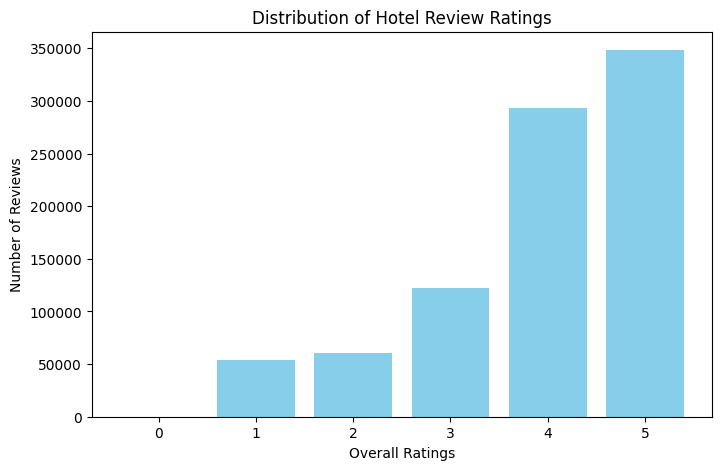

In [25]:
# Plot the distribution of ratings
plt.figure(figsize=(8, 5))
ratings_counts = reviews_df["overall_rating"].value_counts().sort_index()
plt.bar(ratings_counts.index, ratings_counts.values, color="skyblue")
plt.xlabel("Overall Ratings")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Hotel Review Ratings")
plt.xticks(ratings_counts.index)
plt.show()

## Initial Observations

The dataset was loaded successfully and contains hotel review data with a `ratings` column stored as a string representation of a dictionary. Because the project needs a single satisfaction label, the `overall` rating was extracted into a new `overall_rating` column.

The distribution of overall ratings shows how many reviews fall into each rating category. This will be used in the next step to create a binary satisfaction label for classification.

## Review Cleaning and Satisfaction Label Creation

This section prepares the review data for text classification. The `overall_rating` column is used to create a binary satisfaction label, where lower ratings represent dissatisfied reviews and higher ratings represent satisfied reviews.

Cell 1: 

In [2]:
text_column = "text"
rating_column = "overall_rating"

# Check for any null values in the text and rating columns
print(reviews_df[[text_column, rating_column]].isnull().sum())

NameError: name 'reviews_df' is not defined